In [7]:
import numpy as np
import matplotlib.pyplot as plt
from utils import annotated_heatmap, analytical_policy_evaluation
from tabular_methods import rollout_episode, monte_carlo_prediction
from environments import CorridorEnvTerminalReward

We can now instantiate the environment object and some parameters such as the discount factor gamma and the policy

In [9]:
env = CorridorEnvTerminalReward(n_states=10, is_slippery=False)

n_states = env.nS
n_actions = env.nA

possible_actions = np.linspace(0, env.nA-1, env.nA)

pi = [np.ones(n_actions)/n_actions]*n_states # Set the policy to a uniform distribution

In [10]:
def temporal_difference_prediction(alpha: float = 0.9, gamma: float = 1.0, num_episodes: int = 10):
    # Create unique dictionaries for every state and action using list comprehension because dict is mutable
    returns = [[{"avg_return": 0.0, "freq": 0} for _ in range(n_actions)] for _ in range(n_states)]

    # Similarly for the q-table to be safe using list comprehension because list is mutable
    q = [[0.0 for _ in range(n_actions)] for _ in range(n_states)]

    v = [0.0]*n_states # this can be defined using "*" instead of list comprehension because int is immutable

    err = []
    v_analytical = analytical_policy_evaluation(pi, env.model, gamma=gamma)
    
    for e in range(num_episodes):
        done = False
        s = np.random.randint(0,env.nS)
        G = 0
        while not done:
            a = np.random.choice(possible_actions, p=pi[s])
            [p, s_, r, done] = env.step(s, a)[0]
            target = v[s_]*gamma*(not done) + r
            error = target - v[s]
            v[s] += alpha * error
            s = s_
        err.append(sum((v_analytical - v)**2)/n_states)
    return v, err

In [11]:
v, td_err = temporal_difference_prediction(alpha = 0.1, gamma=0.95, num_episodes=100)

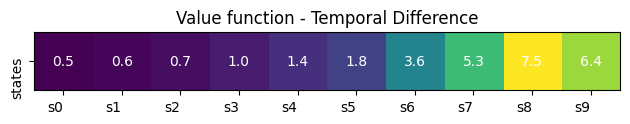

In [12]:
annotated_heatmap([v], "Value function - Temporal Difference")

In [13]:
# Build transition matrix and reward vector under fixed policy
def analytical_policy_evaluation(pi, model, gamma):
    n_states = len(pi)
    n_actions = len(pi[0])
    P = np.zeros((n_states, n_states))
    R = np.zeros(n_states)

    for s in range(n_states):
        for a in range(n_actions):
            for prob, s_prime, reward, done in model[s][a]:
                P[s, s_prime] = pi[s][a]*prob*(not done)
                R[s] += pi[s][a]*reward*prob

    I = np.eye(n_states)
    V = np.linalg.inv(I - gamma * P) @ R

    np.set_printoptions(precision=1, suppress=True)
    return V

In [14]:
V_analytical = analytical_policy_evaluation(pi, env.model, gamma=0.95)

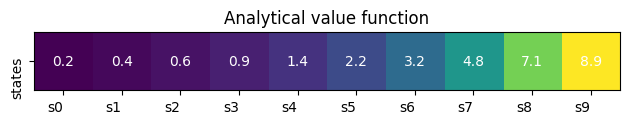

In [15]:
annotated_heatmap([V_analytical], "Analytical value function")

# Compute MSE

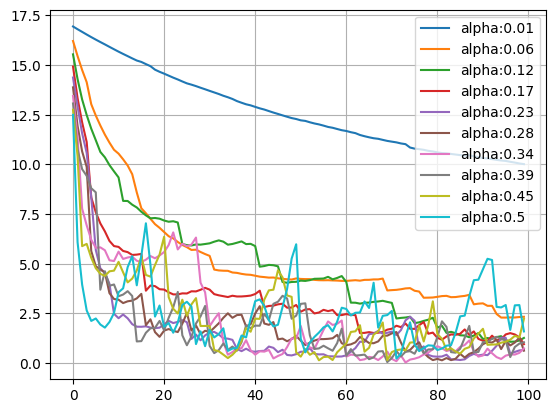

In [16]:
plt.grid()
for alpha in np.linspace(0.01, 0.5, 10):
    _, td_err = temporal_difference_prediction(alpha = alpha, gamma=0.95, num_episodes=100)
    plt.plot(td_err, label="alpha:"+str(round(alpha, 2)))
plt.legend()

Text(0, 0.5, 'MSE')

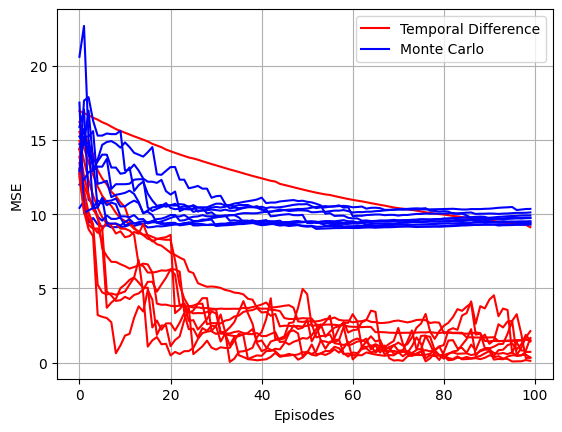

In [19]:
plt.grid()
n_episodes = 100
discount = 0.95
for count, alpha in enumerate(np.linspace(0.01, 0.5, 10)):
    _, td_err = temporal_difference_prediction(alpha = alpha, gamma=discount, num_episodes=n_episodes)
    td_label = "Temporal Difference" if count == 0 else ""
    plt.plot(td_err, label=td_label, color="r")
    mc_label = "Monte Carlo" if count == 0 else ""
    _, mc_err = monte_carlo_prediction(env, pi, gamma=discount, num_episodes=n_episodes)
    plt.plot(mc_err, label=mc_label, color="b")
plt.legend()
plt.xlabel("Episodes")
plt.ylabel("MSE")